In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
WISE_TEAL   = '#00B9A5'
WISE_NAVY   = '#1C3F6E'
WISE_GREEN  = '#2ECC71'
WISE_RED    = '#E74C3C'
WISE_AMBER  = '#F39C12'
WISE_GRAY   = '#64748B'
PALETTE     = [WISE_TEAL, WISE_NAVY, WISE_RED, WISE_AMBER, WISE_GREEN, '#9B59B6']

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFB',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E2E8F0',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'axes.labelcolor':  WISE_GRAY,
    'xtick.color':      WISE_GRAY,
    'ytick.color':      WISE_GRAY,
})

print('Libraries loaded')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✓


## Load Data from SQLite

In [35]:
conn = sqlite3.connect('wise_case.db')

cards = pd.read_sql('SELECT * FROM card', conn, parse_dates=['card_produced_time'])
txn   = pd.read_sql('SELECT * FROM `transaction`', conn, parse_dates=['transaction_time'])  # backticks escape the reserved word
costs = pd.read_sql('SELECT * FROM cost_structure', conn)
rates = pd.read_sql('SELECT * FROM rates', conn)

print(f'Cards:{len(cards):,}')
print(f'Transactions: {len(txn):,}')
print(f'Cost rows:{len(costs)}')
print(f'Rate pairs:{len(rates)}')

Cards:        2,901
Transactions: 18,596
Cost rows:    36
Rate pairs:   163


## Build the Enriched Transaction Table



In [36]:
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS txn_enriched_full")

cursor.execute("""
CREATE TABLE txn_enriched_full AS
WITH successful_txns AS (
    SELECT
        id,
        transaction_time,
        card_token,
        cost_region,
        transaction_type,
        transaction_cost_type,
        amount_currency,
        amount_value,
        billing_amount_currency,
        billing_amount_value,
        interchange_currency,
        inter_change_fee
    FROM "transaction"
    WHERE state = 'SUCCESS'
),
cost_rules AS (
    SELECT
        transaction_cost_type,
        cost_region,
        SUM(CASE WHEN fixed_or_variable = 'Fixed'
                 THEN COALESCE(cost_in_gbp, 0) ELSE 0 END)   AS fixed_cost_gbp,
        SUM(CASE WHEN fixed_or_variable = 'Variable'
                 THEN COALESCE(variable_fee, 0) ELSE 0 END)  AS variable_fee_rate
    FROM cost_structure
    GROUP BY transaction_cost_type, cost_region
),
txn_with_rates AS (
    SELECT
        t.id,
        t.transaction_time,
        t.card_token,
        t.transaction_type,
        t.transaction_cost_type,
        t.cost_region,
        t.amount_currency,
        t.amount_value,
        t.billing_amount_currency,
        t.billing_amount_value,
        t.interchange_currency,
        t.inter_change_fee,
        ar.rate_compared_to_gbp  AS amount_rate_to_gbp,
        br.rate_compared_to_gbp  AS billing_rate_to_gbp,
        ir.rate_compared_to_gbp  AS interchange_rate_to_gbp,
        c.fixed_cost_gbp,
        c.variable_fee_rate
    FROM successful_txns t
    LEFT JOIN rates ar ON t.amount_currency         = ar.code
    LEFT JOIN rates br ON t.billing_amount_currency = br.code
    LEFT JOIN rates ir ON t.interchange_currency    = ir.code
    LEFT JOIN cost_rules c
           ON t.transaction_cost_type = c.transaction_cost_type
          AND t.cost_region           = c.cost_region
),
unit_economics AS (
    SELECT
        id,
        transaction_time,
        card_token,
        transaction_type,
        transaction_cost_type,
        cost_region,
        amount_currency,
        billing_amount_currency,
        amount_value         * amount_rate_to_gbp      AS amount_gbp,
        billing_amount_value * billing_rate_to_gbp     AS billing_amount_gbp,
        inter_change_fee     * interchange_rate_to_gbp AS interchange_revenue_gbp,
        CASE
            WHEN amount_currency <> billing_amount_currency
            THEN (billing_amount_value * billing_rate_to_gbp)
               - (amount_value         * amount_rate_to_gbp)
            ELSE 0
        END                                                       AS conversion_revenue_gbp,
        COALESCE(fixed_cost_gbp, 0)                               AS fixed_cost_gbp,
        (billing_amount_value * billing_rate_to_gbp)
            * COALESCE(variable_fee_rate, 0)                      AS variable_cost_gbp
    FROM txn_with_rates
)
SELECT
    id,
    transaction_time,
    card_token,
    transaction_type,
    transaction_cost_type,
    cost_region,
    amount_currency,
    billing_amount_currency,
    amount_gbp,
    billing_amount_gbp,
    interchange_revenue_gbp,
    conversion_revenue_gbp,
    fixed_cost_gbp,
    variable_cost_gbp,
    interchange_revenue_gbp
        + conversion_revenue_gbp
        - fixed_cost_gbp
        - variable_cost_gbp       AS profit_gbp
FROM unit_economics
""")

conn.commit()

# ── Verify ────────────────────────────────────────────────────────────────
n = pd.read_sql("SELECT COUNT(*) AS n FROM txn_enriched_full", conn).iloc[0, 0]
print(f'Rows in txn_enriched_full: {n:,}')

pd.read_sql("""
    SELECT
        amount_currency,
        billing_amount_currency,
        amount_gbp,
        billing_amount_gbp,
        interchange_revenue_gbp,
        conversion_revenue_gbp,
        fixed_cost_gbp,
        variable_cost_gbp,
        profit_gbp
    FROM txn_enriched_full
    LIMIT 10
""", conn)

Rows in txn_enriched_full: 17,388


,amount_currency,billing_amount_currency,amount_gbp,billing_amount_gbp,interchange_revenue_gbp,conversion_revenue_gbp,fixed_cost_gbp,variable_cost_gbp,profit_gbp
0,EUR,EUR,3.518040,3.518040,0.008795,0,0.060000,-0.001055,-0.050149
1,EUR,EUR,35.180400,35.180400,-0.483731,0,0.060000,0.481971,-1.025702
2,EUR,EUR,35.180400,35.180400,0.070361,0,0.060000,-0.010554,0.020915
3,EUR,EUR,2.198775,2.198775,0.008795,0,0.060000,-0.000660,-0.050545
4,EUR,EUR,17.018519,17.018519,0.035180,0,0.060000,-0.005106,-0.019714
5,GBP,GBP,3.300000,3.300000,0.010000,0,0.059395,-0.006600,-0.042795
6,EUR,EUR,9.665815,9.665815,0.017590,0,0.060000,-0.002900,-0.039510
7,EUR,EUR,2.198775,2.198775,0.008795,0,0.060000,-0.000660,-0.050545
8,EUR,EUR,1.046617,1.046617,0.000000,0,0.060000,-0.000314,-0.059686
9,EUR,EUR,1.583118,1.583118,0.000000,0,0.060000,-0.000475,-0.059525


---
## Q1 — Average Profit by Transaction Type

In [37]:
# ── Q1: Average Profit by Transaction Type ────────────────────────────────
q1 = pd.read_sql("""
    SELECT
        transaction_type,
        COUNT(*)                                    AS txn_count,
        ROUND(AVG(interchange_revenue_gbp), 6)      AS avg_interchange_revenue_gbp,
        ROUND(AVG(conversion_revenue_gbp), 6)       AS avg_conversion_revenue_gbp,
        ROUND(AVG(fixed_cost_gbp), 6)               AS avg_fixed_cost_gbp,
        ROUND(AVG(variable_cost_gbp), 6)            AS avg_variable_cost_gbp,
        ROUND(AVG(profit_gbp), 6)                   AS avg_profit_gbp
    FROM txn_enriched_full
    GROUP BY transaction_type
    ORDER BY avg_profit_gbp DESC
""", conn)

q1

,transaction_type,txn_count,avg_interchange_revenue_gbp,avg_conversion_revenue_gbp,avg_fixed_cost_gbp,avg_variable_cost_gbp,avg_profit_gbp
0,ECOM_PURCHASE,2790,0.224478,-0.033137,0.059638,-0.074255,0.205957
1,POS_PURCHASE,13029,0.087252,-0.018913,0.059754,-0.016099,0.024683
2,CASH_WITHDRAWAL,1569,-0.510105,0.029107,0.059816,0.983256,-1.524071


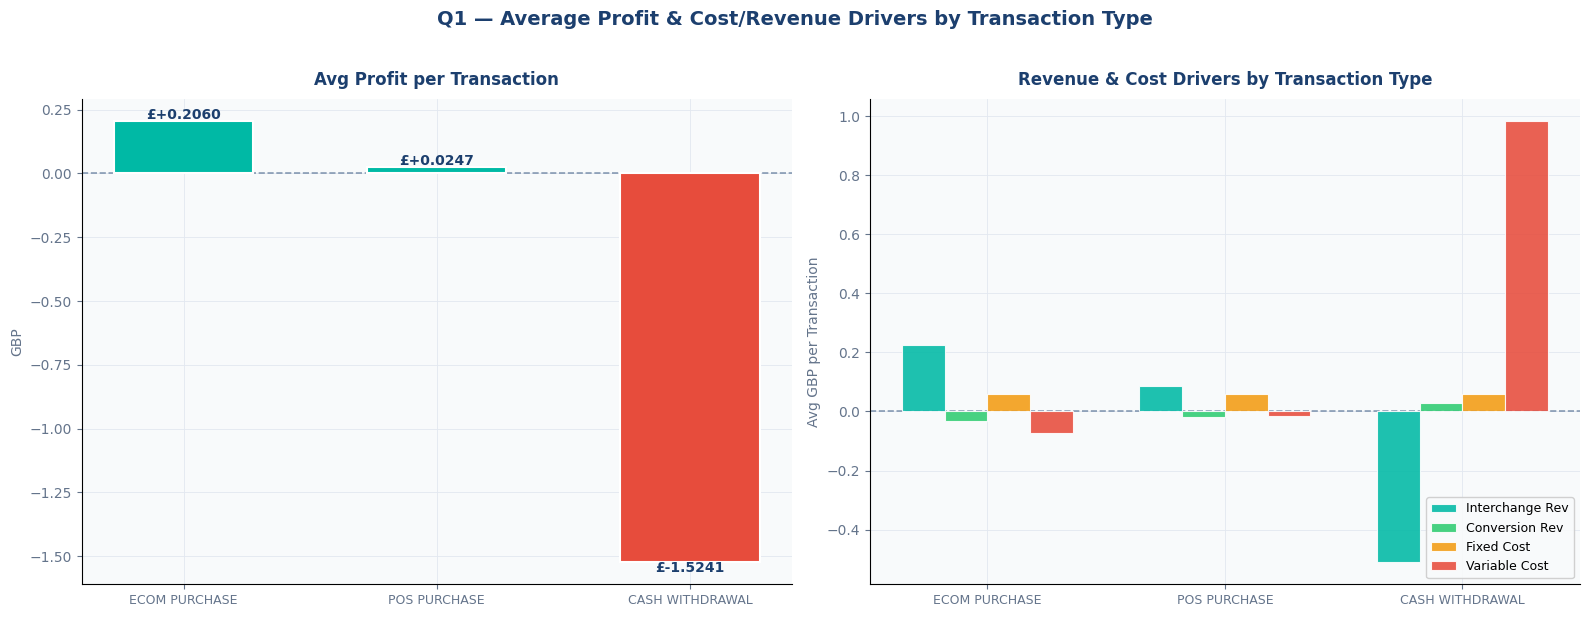

In [38]:
# ── Q1 Visualisation ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

WISE_TEAL  = '#00B9A5'
WISE_NAVY  = '#1C3F6E'
WISE_GREEN = '#2ECC71'
WISE_RED   = '#E74C3C'
WISE_AMBER = '#F39C12'
WISE_GRAY  = '#64748B'

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8FAFB',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#E2E8F0',
    'grid.linewidth':    0.6,
    'font.family':       'sans-serif',
    'axes.labelcolor':   WISE_GRAY,
    'xtick.color':       WISE_GRAY,
    'ytick.color':       WISE_GRAY,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q1 — Average Profit & Cost/Revenue Drivers by Transaction Type',
             fontsize=14, fontweight='bold', color=WISE_NAVY, y=1.02)

types   = q1['transaction_type'].str.replace('_', ' ').tolist()
profits = q1['avg_profit_gbp'].tolist()

# ── LEFT: Avg profit per transaction type ─────────────────────────────────
ax1 = axes[0]
bar_colors = [WISE_TEAL if p > 0 else WISE_RED for p in profits]
bars = ax1.bar(types, profits, color=bar_colors, edgecolor='white',
               linewidth=1.5, width=0.55, zorder=3)
ax1.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)

for bar, val in zip(bars, profits):
    ypos = val + 0.008 if val >= 0 else val - 0.04
    ax1.text(bar.get_x() + bar.get_width() / 2, ypos,
             f'£{val:+.4f}', ha='center', fontweight='bold',
             fontsize=10, color=WISE_NAVY)

ax1.set_title('Avg Profit per Transaction', fontsize=12,
              fontweight='bold', color=WISE_NAVY, pad=10)
ax1.set_ylabel('GBP', fontsize=10)
ax1.tick_params(axis='x', labelsize=9)

# ── RIGHT: Stacked component breakdown ────────────────────────────────────
ax2 = axes[1]

components  = ['avg_interchange_revenue_gbp', 'avg_conversion_revenue_gbp',
               'avg_fixed_cost_gbp',          'avg_variable_cost_gbp']
labels      = ['Interchange Rev', 'Conversion Rev', 'Fixed Cost', 'Variable Cost']
comp_colors = [WISE_TEAL, WISE_GREEN, WISE_AMBER, WISE_RED]

x      = np.arange(len(types))
width  = 0.18
offset = np.linspace(-1.5, 1.5, len(components)) * width

for col, lbl, clr, off in zip(components, labels, comp_colors, offset):
    vals = q1[col].tolist()
    ax2.bar(x + off, vals, width=width, label=lbl,
            color=clr, edgecolor='white', linewidth=0.8, alpha=0.88, zorder=3)

ax2.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(types, fontsize=9)
ax2.set_title('Revenue & Cost Drivers by Transaction Type', fontsize=12,
              fontweight='bold', color=WISE_NAVY, pad=10)
ax2.set_ylabel('Avg GBP per Transaction', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.9, loc='lower right')

plt.tight_layout()
plt.savefig('q1_profit_by_txn_type.png', dpi=150, bbox_inches='tight')
plt.show()

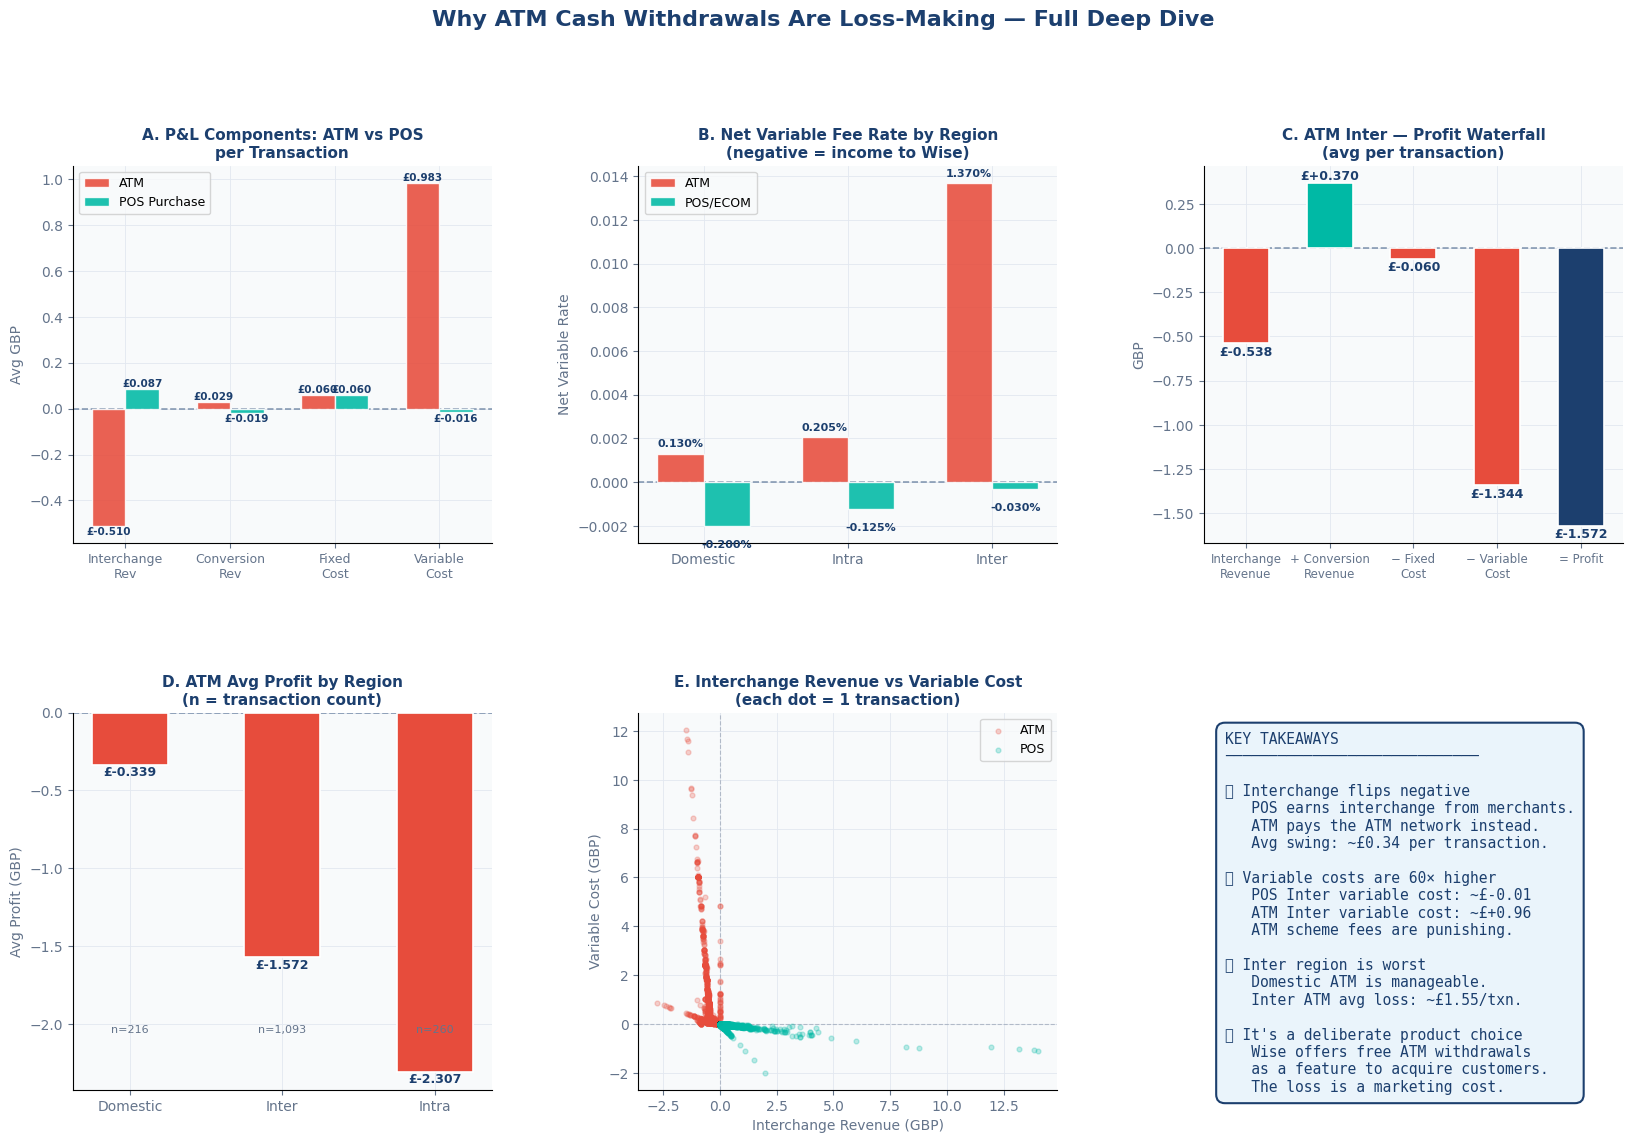

In [39]:
# ── ATM Deep Dive — Full Combined Analysis ────────────────────────────────

# Data pulls
rate_data = pd.read_sql("""
    SELECT
        transaction_cost_type,
        cost_region,
        SUM(CASE WHEN fixed_or_variable = 'Variable'
                 THEN COALESCE(variable_fee, 0) ELSE 0 END) AS total_variable_rate
    FROM cost_structure
    GROUP BY transaction_cost_type, cost_region
    ORDER BY cost_region, transaction_cost_type
""", conn)

atm_inter = pd.read_sql("""
    SELECT
        ROUND(AVG(interchange_revenue_gbp), 4)  AS interchange,
        ROUND(AVG(conversion_revenue_gbp), 4)   AS conversion,
        ROUND(AVG(fixed_cost_gbp), 4)           AS fixed_cost,
        ROUND(AVG(variable_cost_gbp), 4)        AS variable_cost,
        ROUND(AVG(profit_gbp), 4)               AS profit
    FROM txn_enriched_full
    WHERE transaction_type = 'CASH_WITHDRAWAL'
    AND   cost_region      = 'Inter'
""", conn).iloc[0]

atm_row = q1[q1['transaction_type'] == 'CASH_WITHDRAWAL'].iloc[0]
pos_row = q1[q1['transaction_type'] == 'POS_PURCHASE'].iloc[0]

# ── Layout ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

fig.suptitle('Why ATM Cash Withdrawals Are Loss-Making — Full Deep Dive',
             fontsize=16, fontweight='bold', color=WISE_NAVY, y=1.01)

# ── Panel A (top-left): P&L components ATM vs POS ─────────────────────────
ax_a = fig.add_subplot(gs[0, 0])

components = ['avg_interchange_revenue_gbp', 'avg_conversion_revenue_gbp',
              'avg_fixed_cost_gbp',          'avg_variable_cost_gbp']
comp_labels = ['Interchange\nRev', 'Conversion\nRev', 'Fixed\nCost', 'Variable\nCost']
atm_vals    = [atm_row[c] for c in components]
pos_vals    = [pos_row[c] for c in components]

x     = np.arange(len(components))
width = 0.32
bars_a = ax_a.bar(x - width/2, atm_vals, width=width, label='ATM',
                  color=WISE_RED,  edgecolor='white', linewidth=1, alpha=0.88, zorder=3)
bars_p = ax_a.bar(x + width/2, pos_vals, width=width, label='POS Purchase',
                  color=WISE_TEAL, edgecolor='white', linewidth=1, alpha=0.88, zorder=3)

for bar, v in zip(bars_a, atm_vals):
    ypos = v - 0.04 if v < 0 else v + 0.01
    ax_a.text(bar.get_x() + bar.get_width()/2, ypos, f'£{v:.3f}',
              ha='center', fontsize=7.5, fontweight='bold', color=WISE_NAVY)
for bar, v in zip(bars_p, pos_vals):
    ypos = v - 0.04 if v < 0 else v + 0.01
    ax_a.text(bar.get_x() + bar.get_width()/2, ypos, f'£{v:.3f}',
              ha='center', fontsize=7.5, fontweight='bold', color=WISE_NAVY)

ax_a.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
ax_a.set_xticks(x)
ax_a.set_xticklabels(comp_labels, fontsize=9)
ax_a.set_title('A. P&L Components: ATM vs POS\nper Transaction',
               fontweight='bold', color=WISE_NAVY, fontsize=11)
ax_a.set_ylabel('Avg GBP', fontsize=10)
ax_a.legend(fontsize=9)

# ── Panel B (top-middle): Variable fee rates by region ────────────────────
ax_b = fig.add_subplot(gs[0, 1])

regions   = ['Domestic', 'Intra', 'Inter']
atm_rates = [rate_data[(rate_data['transaction_cost_type'] == 'ATM') &
                        (rate_data['cost_region'] == r)]['total_variable_rate'].values[0]
             for r in regions]
pos_rates = [rate_data[(rate_data['transaction_cost_type'] == 'POS/ECOM') &
                        (rate_data['cost_region'] == r)]['total_variable_rate'].values[0]
             for r in regions]

x2    = np.arange(len(regions))
b_atm = ax_b.bar(x2 - width/2, atm_rates, width=width, label='ATM',
                 color=WISE_RED,  edgecolor='white', linewidth=1, alpha=0.88, zorder=3)
b_pos = ax_b.bar(x2 + width/2, pos_rates, width=width, label='POS/ECOM',
                 color=WISE_TEAL, edgecolor='white', linewidth=1, alpha=0.88, zorder=3)

for bar, v in zip(b_atm, atm_rates):
    ypos = v + 0.0003 if v >= 0 else v - 0.001
    ax_b.text(bar.get_x() + bar.get_width()/2, ypos,
              f'{v*100:.3f}%', ha='center', fontsize=8,
              fontweight='bold', color=WISE_NAVY)
for bar, v in zip(b_pos, pos_rates):
    ypos = v + 0.0003 if v >= 0 else v - 0.001
    ax_b.text(bar.get_x() + bar.get_width()/2, ypos,
              f'{v*100:.3f}%', ha='center', fontsize=8,
              fontweight='bold', color=WISE_NAVY)

ax_b.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
ax_b.set_xticks(x2)
ax_b.set_xticklabels(regions, fontsize=10)
ax_b.set_title('B. Net Variable Fee Rate by Region\n(negative = income to Wise)',
               fontweight='bold', color=WISE_NAVY, fontsize=11)
ax_b.set_ylabel('Net Variable Rate', fontsize=10)
ax_b.legend(fontsize=9)

# ── Panel C (top-right): ATM Inter profit waterfall ───────────────────────
ax_c = fig.add_subplot(gs[0, 2])

wf_labels = ['Interchange\nRevenue', '+ Conversion\nRevenue',
             '− Fixed\nCost',        '− Variable\nCost', '= Profit']
wf_vals   = [atm_inter['interchange'],  atm_inter['conversion'],
             -atm_inter['fixed_cost'],  -atm_inter['variable_cost'],
             atm_inter['profit']]
wf_colors = [WISE_TEAL if v >= 0 else WISE_RED for v in wf_vals]
wf_colors[-1] = WISE_NAVY

bars_c = ax_c.bar(wf_labels, wf_vals, color=wf_colors,
                  edgecolor='white', linewidth=1.2, width=0.55, zorder=3)
for bar, v in zip(bars_c, wf_vals):
    ypos = v + 0.02 if v >= 0 else v - 0.07
    ax_c.text(bar.get_x() + bar.get_width()/2, ypos,
              f'£{v:+.3f}', ha='center', fontsize=9,
              fontweight='bold', color=WISE_NAVY)

ax_c.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
ax_c.set_title('C. ATM Inter — Profit Waterfall\n(avg per transaction)',
               fontweight='bold', color=WISE_NAVY, fontsize=11)
ax_c.set_ylabel('GBP', fontsize=10)
ax_c.tick_params(axis='x', labelsize=8.5)

# ── Panel D (bottom-left): ATM profit by region ───────────────────────────
ax_d = fig.add_subplot(gs[1, 0])

atm_by_region = pd.read_sql("""
    SELECT
        cost_region,
        COUNT(*)                                AS txn_count,
        ROUND(AVG(interchange_revenue_gbp), 4)  AS avg_interchange,
        ROUND(AVG(variable_cost_gbp), 4)        AS avg_variable_cost,
        ROUND(AVG(profit_gbp), 4)               AS avg_profit
    FROM txn_enriched_full
    WHERE transaction_type = 'CASH_WITHDRAWAL'
    GROUP BY cost_region
    ORDER BY avg_profit DESC
""", conn)

region_colors = [WISE_TEAL if v > 0 else WISE_RED
                 for v in atm_by_region['avg_profit']]
bars_d = ax_d.bar(atm_by_region['cost_region'], atm_by_region['avg_profit'],
                  color=region_colors, edgecolor='white',
                  linewidth=1.2, width=0.5, zorder=3)
for bar, v in zip(bars_d, atm_by_region['avg_profit']):
    ypos = v + 0.02 if v >= 0 else v - 0.07
    ax_d.text(bar.get_x() + bar.get_width()/2, ypos,
              f'£{v:+.3f}', ha='center', fontsize=9,
              fontweight='bold', color=WISE_NAVY)

# annotate txn counts
for bar, n in zip(bars_d, atm_by_region['txn_count']):
    ax_d.text(bar.get_x() + bar.get_width()/2,
              ax_d.get_ylim()[0] * 0.85,
              f'n={n:,}', ha='center', fontsize=8, color=WISE_GRAY)

ax_d.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
ax_d.set_title('D. ATM Avg Profit by Region\n(n = transaction count)',
               fontweight='bold', color=WISE_NAVY, fontsize=11)
ax_d.set_ylabel('Avg Profit (GBP)', fontsize=10)

# ── Panel E (bottom-middle): Interchange vs variable cost scatter ──────────
ax_e = fig.add_subplot(gs[1, 1])

scatter_data = pd.read_sql("""
    SELECT
        transaction_type,
        interchange_revenue_gbp,
        variable_cost_gbp,
        profit_gbp
    FROM txn_enriched_full
    WHERE transaction_type IN ('CASH_WITHDRAWAL', 'POS_PURCHASE')
""", conn)

for ttype, clr, lbl in [('CASH_WITHDRAWAL', WISE_RED,  'ATM'),
                          ('POS_PURCHASE',    WISE_TEAL, 'POS')]:
    sub = scatter_data[scatter_data['transaction_type'] == ttype]
    ax_e.scatter(sub['interchange_revenue_gbp'], sub['variable_cost_gbp'],
                 alpha=0.25, s=12, color=clr, label=lbl, zorder=3)

ax_e.axhline(0, color=WISE_GRAY,  linewidth=0.8, linestyle='--', alpha=0.4)
ax_e.axvline(0, color=WISE_GRAY,  linewidth=0.8, linestyle='--', alpha=0.4)
ax_e.set_title('E. Interchange Revenue vs Variable Cost\n(each dot = 1 transaction)',
               fontweight='bold', color=WISE_NAVY, fontsize=11)
ax_e.set_xlabel('Interchange Revenue (GBP)', fontsize=10)
ax_e.set_ylabel('Variable Cost (GBP)', fontsize=10)
ax_e.legend(fontsize=9)

# ── Panel F (bottom-right): Summary insight text box ─────────────────────
ax_f = fig.add_subplot(gs[1, 2])
ax_f.axis('off')

summary = (
    "KEY TAKEAWAYS\n"
    "─────────────────────────────\n\n"
    "① Interchange flips negative\n"
    "   POS earns interchange from merchants.\n"
    "   ATM pays the ATM network instead.\n"
    "   Avg swing: ~£0.34 per transaction.\n\n"
    "② Variable costs are 60× higher\n"
    "   POS Inter variable cost: ~£-0.01\n"
    "   ATM Inter variable cost: ~£+0.96\n"
    "   ATM scheme fees are punishing.\n\n"
    "③ Inter region is worst\n"
    "   Domestic ATM is manageable.\n"
    "   Inter ATM avg loss: ~£1.55/txn.\n\n"
    "④ It's a deliberate product choice\n"
    "   Wise offers free ATM withdrawals\n"
    "   as a feature to acquire customers.\n"
    "   The loss is a marketing cost."
)

ax_f.text(0.05, 0.95, summary,
          transform=ax_f.transAxes,
          fontsize=10.5, verticalalignment='top',
          fontfamily='monospace', color=WISE_NAVY,
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#EAF4FB',
                    edgecolor=WISE_NAVY, linewidth=1.5))

plt.savefig('atm_deep_dive_combined.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Q2 — 12-Month Lifetime Value (LTV)

In [58]:
pd.read_sql("""
    WITH card_obs AS (
        SELECT
            c.card_token,
            c.profile_address_country,
            COUNT(t.id)                              AS txn_count,
            COALESCE(SUM(t.profit_gbp), 0)           AS total_observed_profit,
            julianday(MAX(t.transaction_time))
                - julianday(c.card_produced_time)    AS observed_days
        FROM card c
        LEFT JOIN txn_enriched_full t ON c.card_token = t.card_token
        GROUP BY c.card_token, c.card_produced_time, c.profile_address_country
    ),
    card_ltv AS (
        SELECT
            card_token,
            profile_address_country,
            txn_count,
            observed_days,
            total_observed_profit,
            CASE
                WHEN observed_days >= 30
                THEN (total_observed_profit / observed_days) * 365
                WHEN txn_count > 0
                THEN total_observed_profit
                ELSE 0
            END AS ltv_12m
        FROM card_obs
    )
    SELECT
        -- headline numbers
        COUNT(*)                                             AS total_cards,
        SUM(CASE WHEN txn_count = 0  THEN 1 ELSE 0 END)    AS inactive_cards,
        SUM(CASE WHEN txn_count > 0
                 AND observed_days < 30 THEN 1 ELSE 0 END) AS cards_under_30d,
        SUM(CASE WHEN observed_days >= 30 THEN 1 ELSE 0 END) AS extrapolated_cards,
        -- LTV figures
        ROUND(AVG(ltv_12m), 4)                             AS avg_ltv_12m_all_cards,
        ROUND(AVG(CASE WHEN observed_days >= 30
                       THEN ltv_12m END), 4)               AS avg_ltv_12m_active_only,
        ROUND(SUM(ltv_12m), 2)                             AS total_forecast_profit_12m
    FROM card_ltv
""", conn)

,total_cards,inactive_cards,cards_under_30d,extrapolated_cards,avg_ltv_12m_all_cards,avg_ltv_12m_active_only,total_forecast_profit_12m
0,2901,1894,381,626,-2.6895,-11.9822,-7802.28


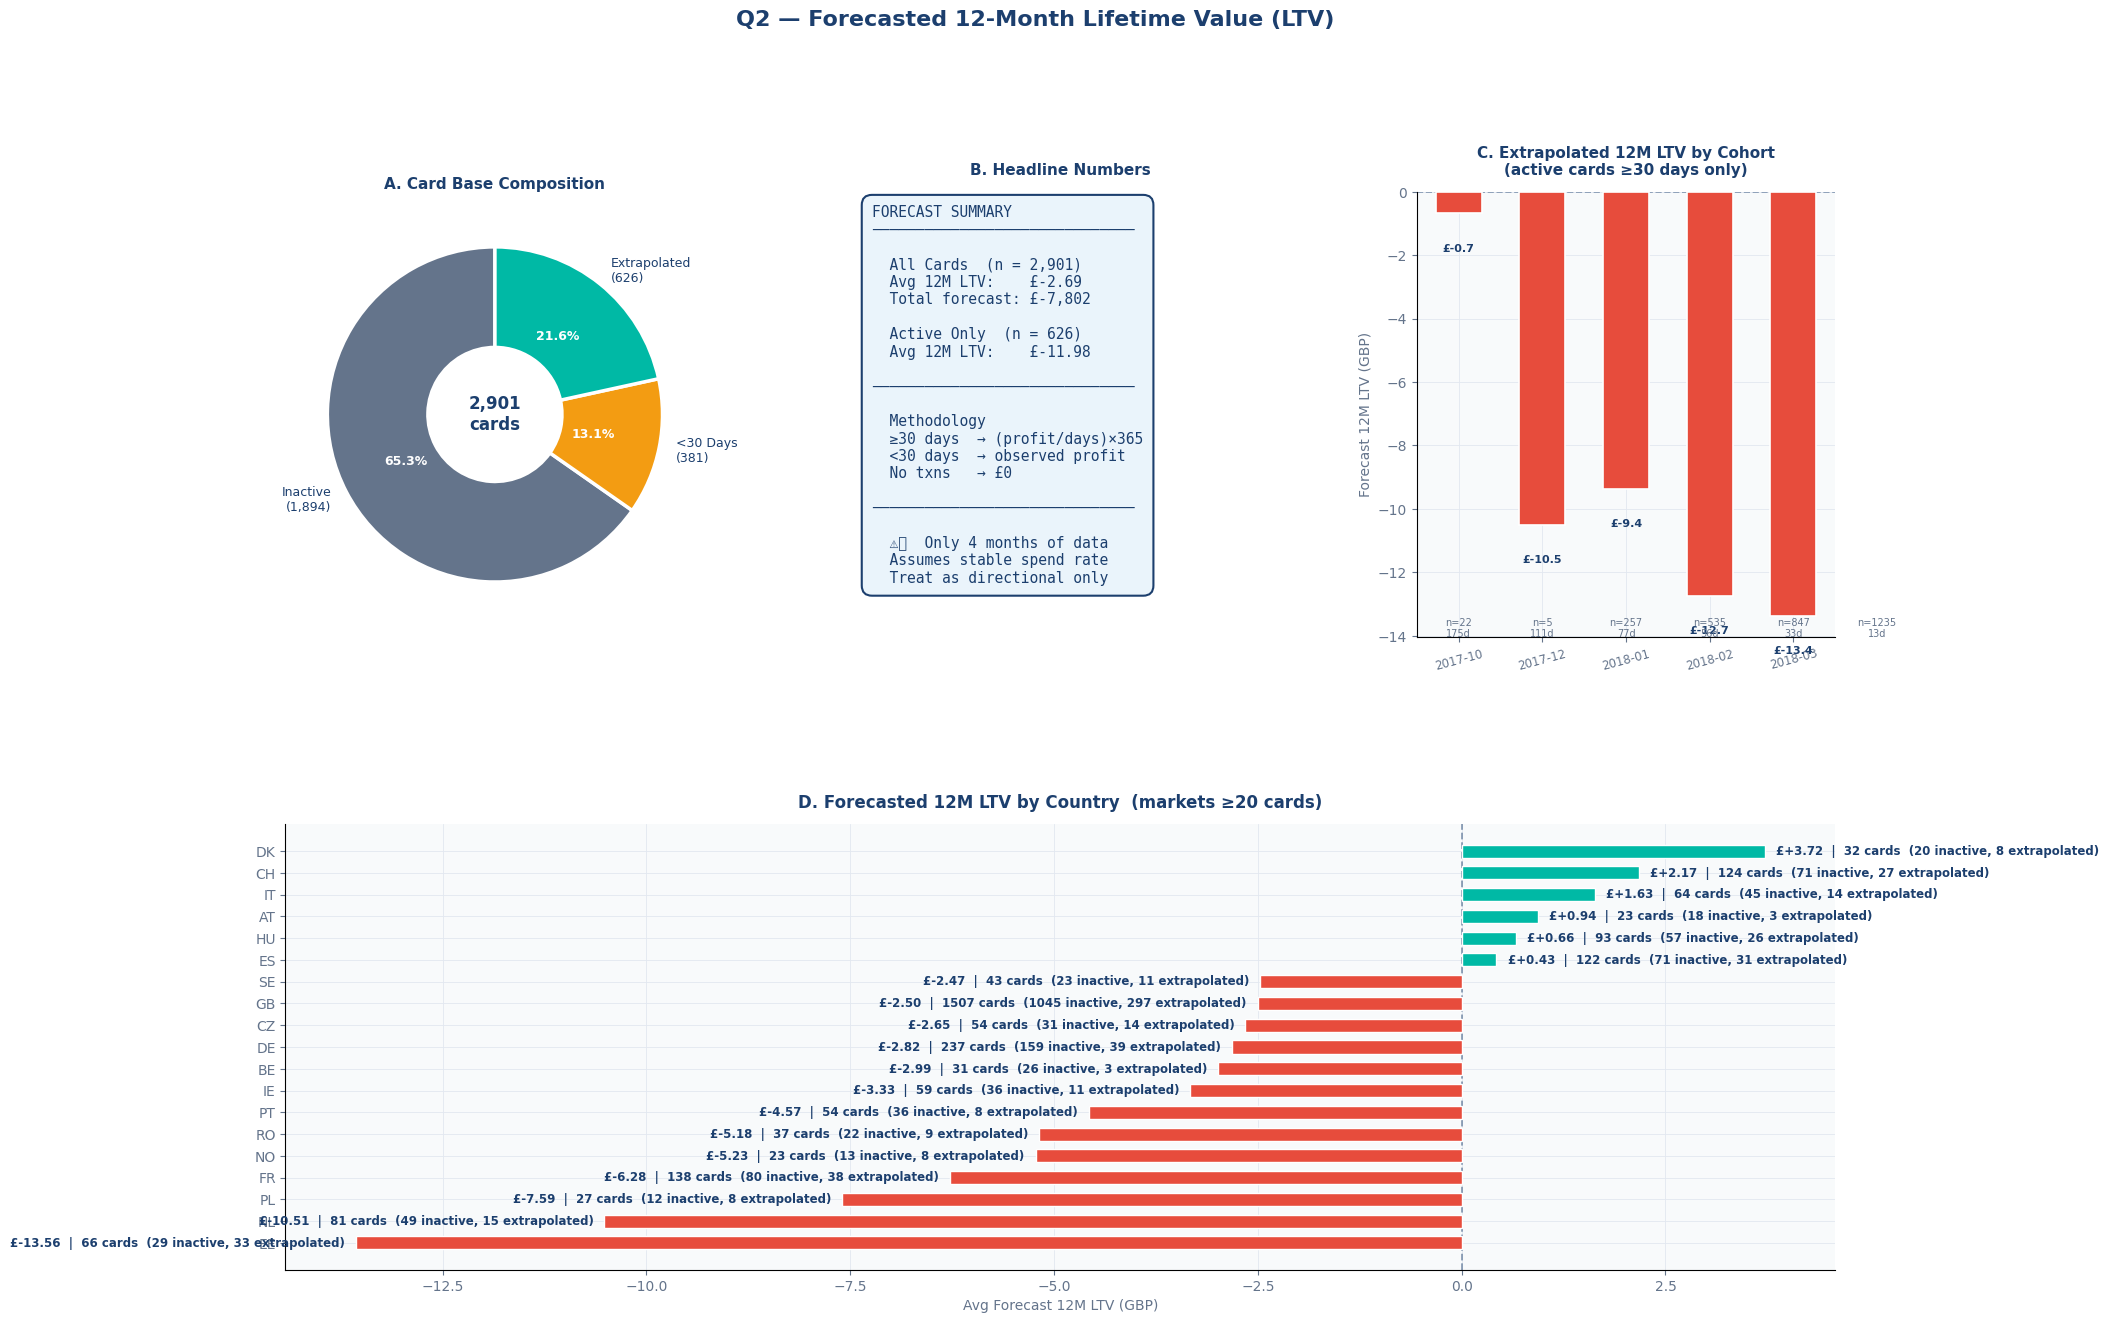

In [59]:
# ── Visualisation ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

fig.suptitle('Q2 — Forecasted 12-Month Lifetime Value (LTV)',
             fontsize=16, fontweight='bold', color=WISE_NAVY, y=1.01)

# ── Panel A: Card base donut ───────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])

sizes  = [int(q2_headline['inactive_cards']),
          int(q2_headline['cards_under_30d']),
          int(q2_headline['extrapolated_cards'])]
labels = [f"Inactive\n({sizes[0]:,})",
          f"<30 Days\n({sizes[1]:,})",
          f"Extrapolated\n({sizes[2]:,})"]
colors = [WISE_GRAY, WISE_AMBER, WISE_TEAL]

wedges, texts, autotexts = ax_a.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5, width=0.6),
    textprops=dict(fontsize=9, color=WISE_NAVY)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
    at.set_color('white')

ax_a.text(0, 0, f"{int(q2_headline['total_cards']):,}\ncards",
          ha='center', va='center',
          fontsize=12, fontweight='bold', color=WISE_NAVY)
ax_a.set_title('A. Card Base Composition',
               fontweight='bold', color=WISE_NAVY, fontsize=11, pad=12)

# ── Panel B: KPI summary box ──────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.axis('off')

kpi_text = (
    "FORECAST SUMMARY\n"
    "──────────────────────────────\n\n"
    f"  All Cards  (n = {int(q2_headline['total_cards']):,})\n"
    f"  Avg 12M LTV:    £{q2_headline['avg_ltv_12m_all_cards']:+.2f}\n"
    f"  Total forecast: £{q2_headline['total_forecast_profit_12m']:,.0f}\n\n"
    f"  Active Only  (n = {int(q2_headline['extrapolated_cards']):,})\n"
    f"  Avg 12M LTV:    £{q2_headline['avg_ltv_12m_active_only']:+.2f}\n\n"
    "──────────────────────────────\n\n"
    "  Methodology\n"
    "  ≥30 days  → (profit/days)×365\n"
    "  <30 days  → observed profit\n"
    "  No txns   → £0\n\n"
    "──────────────────────────────\n\n"
    "  Only 4 months of data\n"
    "  Assumes stable spend rate\n"
    "  Treat as directional only"
)
ax_b.text(0.05, 0.97, kpi_text,
          transform=ax_b.transAxes,
          fontsize=10.5, verticalalignment='top',
          fontfamily='monospace', color=WISE_NAVY,
          bbox=dict(boxstyle='round,pad=0.7', facecolor='#EAF4FB',
                    edgecolor=WISE_NAVY, linewidth=1.5))
ax_b.set_title('B. Headline Numbers',
               fontweight='bold', color=WISE_NAVY, fontsize=11, pad=12)

# ── Panel C: Cohort extrapolated LTV ──────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])

c_colors = [WISE_TEAL if v > 0 else WISE_RED
            for v in cohort_data['extrapolated_12m_ltv']]
bars_c = ax_c.bar(cohort_data['cohort_month'],
                  cohort_data['extrapolated_12m_ltv'],
                  color=c_colors, edgecolor='white',
                  linewidth=1.2, width=0.55, zorder=3)

y_min = cohort_data['extrapolated_12m_ltv'].min()
for bar, v, n, d in zip(bars_c,
                         cohort_data['extrapolated_12m_ltv'],
                         cohort_data['num_cards'],
                         cohort_data['avg_observed_days']):
    ypos = v + 0.3 if v >= 0 else v - 1.2
    ax_c.text(bar.get_x() + bar.get_width()/2, ypos,
              f'£{v:.1f}', ha='center', fontsize=8,
              fontweight='bold', color=WISE_NAVY)
    ax_c.text(bar.get_x() + bar.get_width()/2,
              y_min * 1.05,
              f'n={n}\n{d:.0f}d',
              ha='center', fontsize=7, color=WISE_GRAY)

ax_c.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
ax_c.set_title('C. Extrapolated 12M LTV by Cohort\n(active cards ≥30 days only)',
               fontweight='bold', color=WISE_NAVY, fontsize=11, pad=12)
ax_c.set_ylabel('Forecast 12M LTV (GBP)', fontsize=10)
ax_c.tick_params(axis='x', labelsize=8.5, rotation=15)

# ── Panel D: LTV by country (full width bottom) ───────────────────────────
ax_d = fig.add_subplot(gs[1, :])

q2_sorted = q2_country.sort_values('avg_ltv_12m', ascending=True)
d_colors  = [WISE_TEAL if v > 0 else WISE_RED
             for v in q2_sorted['avg_ltv_12m']]

bars_d = ax_d.barh(q2_sorted['profile_address_country'],
                   q2_sorted['avg_ltv_12m'],
                   color=d_colors, edgecolor='white',
                   linewidth=1, height=0.6, zorder=3)

ax_d.axvline(0, color=WISE_NAVY, linewidth=1.3, linestyle='--', alpha=0.5)

x_range = q2_sorted['avg_ltv_12m'].abs().max()
for bar, v, total, inactive, extrap in zip(
        bars_d,
        q2_sorted['avg_ltv_12m'],
        q2_sorted['total_cards'],
        q2_sorted['inactive_cards'],
        q2_sorted['extrapolated_cards']):
    xpos = v + x_range * 0.01 if v >= 0 else v - x_range * 0.01
    ha   = 'left' if v >= 0 else 'right'
    ax_d.text(xpos, bar.get_y() + bar.get_height()/2,
              f'£{v:+.2f}  |  {total} cards  '
              f'({inactive} inactive, {extrap} extrapolated)',
              va='center', ha=ha, fontsize=8.5,
              fontweight='bold', color=WISE_NAVY)

ax_d.set_title('D. Forecasted 12M LTV by Country  (markets ≥20 cards)',
               fontweight='bold', color=WISE_NAVY, fontsize=12, pad=12)
ax_d.set_xlabel('Avg Forecast 12M LTV (GBP)', fontsize=10)
ax_d.tick_params(axis='y', labelsize=10)

plt.savefig('q2_ltv_full.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Q3 — Market Performance

In [60]:
# ── Q3 data pulls ─────────────────────────────────────────────────────────

# A. Market performance summary
mkt_perf = pd.read_sql("""
    SELECT
        c.profile_address_country                           AS country,
        COUNT(t.id)                                         AS txn_count,
        COUNT(DISTINCT t.card_token)                        AS active_cards,
        ROUND(SUM(t.profit_gbp), 2)                         AS total_profit,
        ROUND(AVG(t.profit_gbp), 4)                         AS avg_profit_per_txn,
        ROUND(AVG(t.billing_amount_gbp), 4)                 AS avg_billing_gbp,
        ROUND(AVG(CASE WHEN t.amount_currency
                            != t.billing_amount_currency
                       THEN 1.0 ELSE 0.0 END), 4)          AS pct_fx_txns,
        ROUND(AVG(t.interchange_revenue_gbp), 4)            AS avg_interchange,
        ROUND(AVG(t.conversion_revenue_gbp), 4)             AS avg_conversion_rev,
        ROUND(AVG(t.variable_cost_gbp), 4)                  AS avg_variable_cost,
        ROUND(AVG(t.fixed_cost_gbp), 4)                     AS avg_fixed_cost
    FROM txn_enriched_full t
    JOIN card c ON t.card_token = c.card_token
    GROUP BY c.profile_address_country
    HAVING COUNT(t.id) >= 50
    ORDER BY total_profit DESC
""", conn)

# B. Transaction type mix by country
txn_mix = pd.read_sql("""
    SELECT
        c.profile_address_country                           AS country,
        t.transaction_type,
        COUNT(*)                                            AS txn_count,
        ROUND(AVG(t.profit_gbp), 4)                         AS avg_profit
    FROM txn_enriched_full t
    JOIN card c ON t.card_token = c.card_token
    GROUP BY c.profile_address_country, t.transaction_type
    HAVING COUNT(*) >= 10
    ORDER BY country, txn_count DESC
""", conn)

# C. Region mix by country
region_mix = pd.read_sql("""
    SELECT
        c.profile_address_country                           AS country,
        t.cost_region,
        COUNT(*)                                            AS txn_count,
        ROUND(AVG(t.profit_gbp), 4)                         AS avg_profit
    FROM txn_enriched_full t
    JOIN card c ON t.card_token = c.card_token
    GROUP BY c.profile_address_country, t.cost_region
    HAVING COUNT(*) >= 10
    ORDER BY country, txn_count DESC
""", conn)

# D. Monthly volume trend by country
monthly_trend = pd.read_sql("""
    SELECT
        c.profile_address_country                           AS country,
        strftime('%Y-%m', t.transaction_time)               AS month,
        COUNT(*)                                            AS txn_count,
        ROUND(SUM(t.profit_gbp), 4)                         AS monthly_profit
    FROM txn_enriched_full t
    JOIN card c ON t.card_token = c.card_token
    GROUP BY c.profile_address_country, month
    ORDER BY country, month
""", conn)

print('mkt_perf:', mkt_perf.shape)
print('txn_mix:', txn_mix.shape)
print('region_mix:', region_mix.shape)
print('monthly_trend:', monthly_trend.shape)
mkt_perf

mkt_perf: (22, 11)
txn_mix: (66, 4)
region_mix: (63, 4)
monthly_trend: (85, 4)


,country,txn_count,active_cards,total_profit,avg_profit_per_txn,avg_billing_gbp,pct_fx_txns,avg_interchange,avg_conversion_rev,avg_variable_cost,avg_fixed_cost
0,ES,625,51,50.86,0.0814,48.5814,0.2800,0.0692,0.2012,0.1292,0.0598
1,CH,757,53,49.42,0.0653,47.9486,0.1506,0.1515,-0.0387,-0.0122,0.0597
2,FI,171,9,40.16,0.2348,14.8546,0.4211,0.0795,0.2094,-0.0057,0.0597
3,IT,346,19,23.82,0.0689,43.3205,0.3064,0.1032,0.0918,0.0663,0.0599
4,DK,328,12,16.32,0.0498,25.5206,0.2988,0.1404,-0.0302,0.0008,0.0596
5,HU,721,36,12.94,0.0179,18.1751,0.6838,0.0052,0.1345,0.0620,0.0598
6,SK,105,5,6.27,0.0597,12.5744,0.3429,0.0335,0.0902,0.0041,0.0599
7,AT,114,5,2.22,0.0195,16.8055,0.5789,0.0444,0.0318,-0.0032,0.0598
8,MT,59,8,-5.47,-0.0927,51.6374,0.0169,-0.0083,0.0787,0.1031,0.0599
9,SI,57,1,-6.07,-0.1064,12.6797,0.0877,-0.0577,0.0667,0.0554,0.0600


In [61]:
# ── Prep ──────────────────────────────────────────────────────────────────
top_countries = mkt_perf['country'].tolist()

# Pivot transaction type mix
txn_pivot = (txn_mix[txn_mix['country'].isin(top_countries)]
             .pivot_table(index='country', columns='transaction_type',
                          values='txn_count', fill_value=0))
txn_pivot_pct = txn_pivot.div(txn_pivot.sum(axis=1), axis=0) * 100

# Pivot region mix
region_pivot = (region_mix[region_mix['country'].isin(top_countries)]
                .pivot_table(index='country', columns='cost_region',
                             values='txn_count', fill_value=0))
region_pivot_pct = region_pivot.div(region_pivot.sum(axis=1), axis=0) * 100

# Sort countries by total profit for consistent ordering
mkt_sorted = mkt_perf.sort_values('total_profit', ascending=False)
country_order = mkt_sorted['country'].tolist()

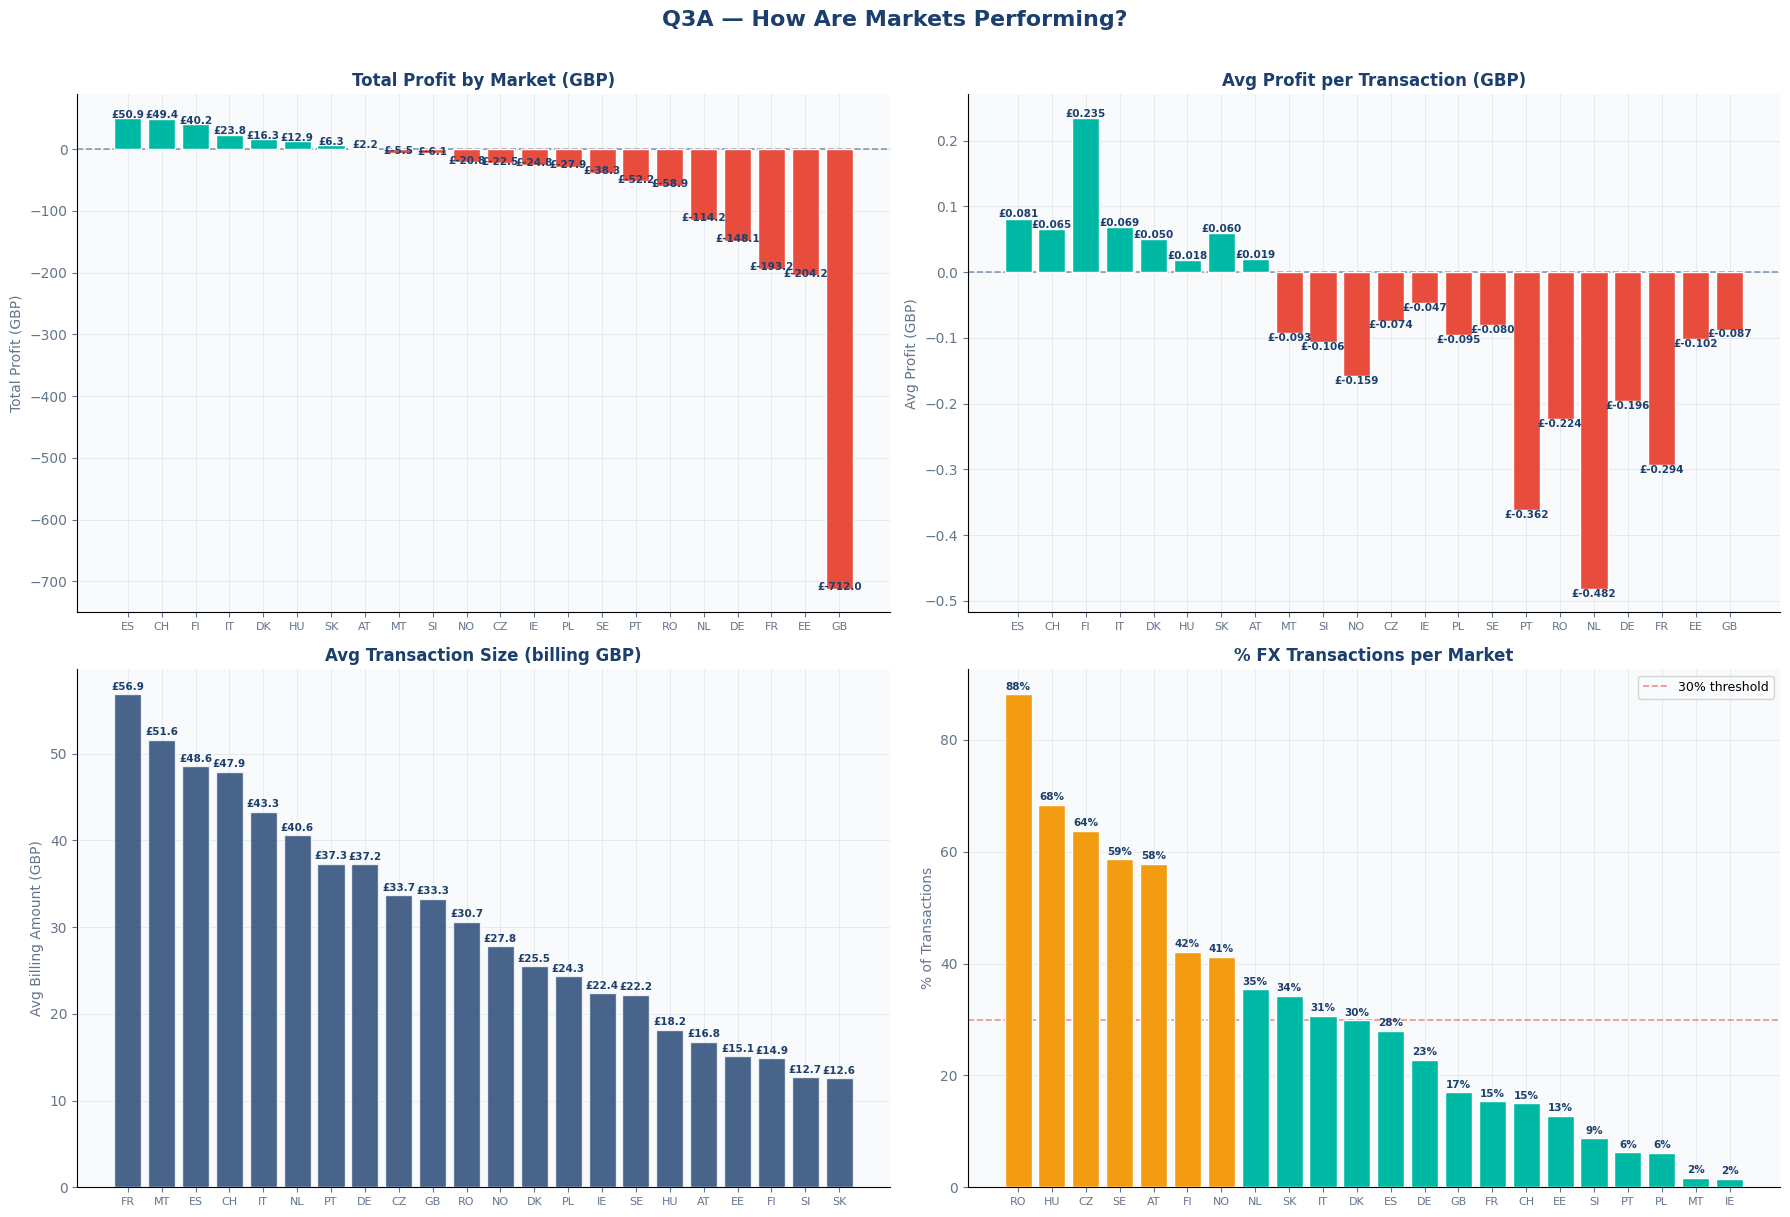

In [62]:
# ── Part A: Market Performance Dashboard ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Q3A — How Are Markets Performing?',
             fontsize=16, fontweight='bold', color=WISE_NAVY, y=1.01)

# Panel 1: Total profit by country
ax = axes[0, 0]
colors_p = [WISE_TEAL if v > 0 else WISE_RED
            for v in mkt_sorted['total_profit']]
bars = ax.bar(mkt_sorted['country'], mkt_sorted['total_profit'],
              color=colors_p, edgecolor='white', linewidth=1, zorder=3)
ax.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
for bar, v in zip(bars, mkt_sorted['total_profit']):
    ypos = v + 0.5 if v >= 0 else v - 2.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'£{v:.1f}', ha='center', fontsize=7.5,
            fontweight='bold', color=WISE_NAVY)
ax.set_title('Total Profit by Market (GBP)', fontweight='bold', color=WISE_NAVY)
ax.set_ylabel('Total Profit (GBP)')
ax.tick_params(axis='x', labelsize=8)

# Panel 2: Avg profit per transaction
ax = axes[0, 1]
colors_a = [WISE_TEAL if v > 0 else WISE_RED
            for v in mkt_sorted['avg_profit_per_txn']]
bars2 = ax.bar(mkt_sorted['country'], mkt_sorted['avg_profit_per_txn'],
               color=colors_a, edgecolor='white', linewidth=1, zorder=3)
ax.axhline(0, color=WISE_NAVY, linewidth=1.2, linestyle='--', alpha=0.5)
for bar, v in zip(bars2, mkt_sorted['avg_profit_per_txn']):
    ypos = v + 0.002 if v >= 0 else v - 0.012
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'£{v:.3f}', ha='center', fontsize=7.5,
            fontweight='bold', color=WISE_NAVY)
ax.set_title('Avg Profit per Transaction (GBP)', fontweight='bold', color=WISE_NAVY)
ax.set_ylabel('Avg Profit (GBP)')
ax.tick_params(axis='x', labelsize=8)

# Panel 3: Avg billing amount (transaction size)
ax = axes[1, 0]
mkt_bill = mkt_sorted.sort_values('avg_billing_gbp', ascending=False)
ax.bar(mkt_bill['country'], mkt_bill['avg_billing_gbp'],
       color=WISE_NAVY, edgecolor='white', linewidth=1,
       alpha=0.8, zorder=3)
for i, (_, row) in enumerate(mkt_bill.iterrows()):
    ax.text(i, row['avg_billing_gbp'] + 0.5,
            f'£{row["avg_billing_gbp"]:.1f}',
            ha='center', fontsize=7.5, fontweight='bold', color=WISE_NAVY)
ax.set_title('Avg Transaction Size (billing GBP)', fontweight='bold', color=WISE_NAVY)
ax.set_ylabel('Avg Billing Amount (GBP)')
ax.tick_params(axis='x', labelsize=8)

# Panel 4: % FX transactions
ax = axes[1, 1]
mkt_fx = mkt_sorted.sort_values('pct_fx_txns', ascending=False)
fx_colors = [WISE_AMBER if v > 0.4 else WISE_TEAL
             for v in mkt_fx['pct_fx_txns']]
ax.bar(mkt_fx['country'], mkt_fx['pct_fx_txns'] * 100,
       color=fx_colors, edgecolor='white', linewidth=1, zorder=3)
ax.axhline(30, color=WISE_RED, linewidth=1.2, linestyle='--',
           alpha=0.6, label='30% threshold')
for i, (_, row) in enumerate(mkt_fx.iterrows()):
    ax.text(i, row['pct_fx_txns'] * 100 + 0.8,
            f'{row["pct_fx_txns"]*100:.0f}%',
            ha='center', fontsize=7.5, fontweight='bold', color=WISE_NAVY)
ax.set_title('% FX Transactions per Market', fontweight='bold', color=WISE_NAVY)
ax.set_ylabel('% of Transactions')
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('q3a_market_performance.png', dpi=150, bbox_inches='tight')
plt.show()

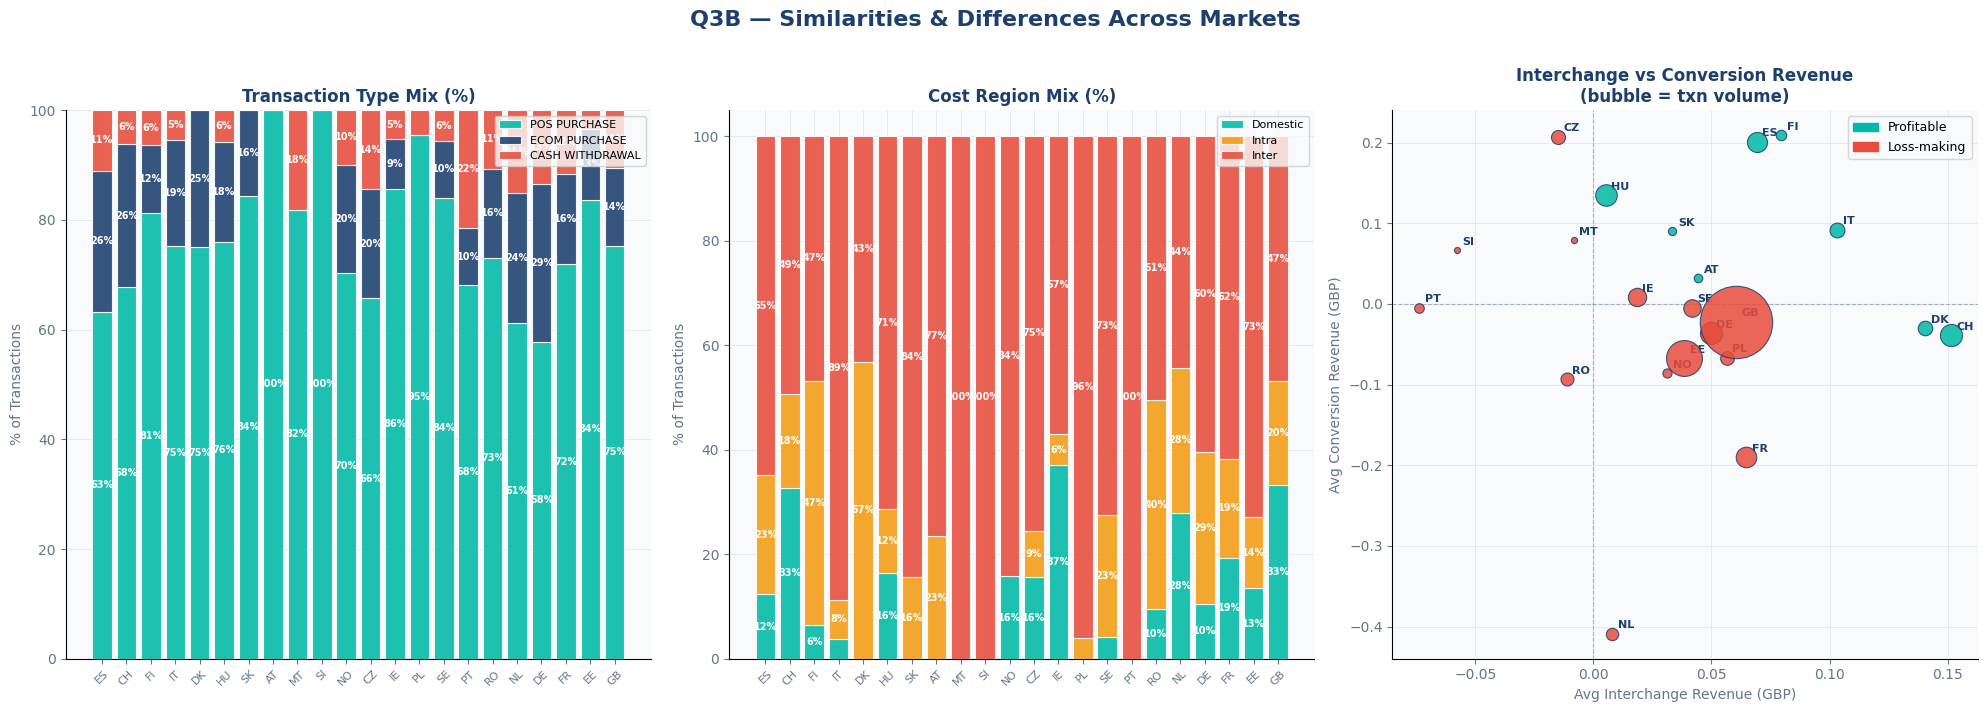

In [63]:
# ── Part B: Similarities & Differences ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Q3B — Similarities & Differences Across Markets',
             fontsize=16, fontweight='bold', color=WISE_NAVY, y=1.01)

# Panel 1: Transaction type mix (stacked bar)
ax = axes[0]
txn_plot = txn_pivot_pct.reindex(country_order).fillna(0)
txn_colors = {'POS_PURCHASE': WISE_TEAL,
              'ECOM_PURCHASE': WISE_NAVY,
              'CASH_WITHDRAWAL': WISE_RED}
bottom = np.zeros(len(txn_plot))
for col in ['POS_PURCHASE', 'ECOM_PURCHASE', 'CASH_WITHDRAWAL']:
    if col in txn_plot.columns:
        vals = txn_plot[col].values
        ax.bar(txn_plot.index, vals, bottom=bottom,
               label=col.replace('_', ' '),
               color=txn_colors[col], edgecolor='white',
               linewidth=0.8, alpha=0.88, zorder=3)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 5:
                ax.text(i, b + v/2, f'{v:.0f}%',
                        ha='center', va='center',
                        fontsize=7, fontweight='bold', color='white')
        bottom += vals

ax.set_title('Transaction Type Mix (%)',
             fontweight='bold', color=WISE_NAVY)
ax.set_ylabel('% of Transactions')
ax.legend(fontsize=8, loc='upper right')
ax.tick_params(axis='x', labelsize=8, rotation=45)

# Panel 2: Cost region mix (stacked bar)
ax = axes[1]
reg_plot = region_pivot_pct.reindex(country_order).fillna(0)
reg_colors = {'Domestic': WISE_TEAL,
              'Intra': WISE_AMBER,
              'Inter': WISE_RED}
bottom = np.zeros(len(reg_plot))
for col in ['Domestic', 'Intra', 'Inter']:
    if col in reg_plot.columns:
        vals = reg_plot[col].values
        ax.bar(reg_plot.index, vals, bottom=bottom,
               label=col, color=reg_colors[col],
               edgecolor='white', linewidth=0.8,
               alpha=0.88, zorder=3)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 5:
                ax.text(i, b + v/2, f'{v:.0f}%',
                        ha='center', va='center',
                        fontsize=7, fontweight='bold', color='white')
        bottom += vals

ax.set_title('Cost Region Mix (%)',
             fontweight='bold', color=WISE_NAVY)
ax.set_ylabel('% of Transactions')
ax.legend(fontsize=8, loc='upper right')
ax.tick_params(axis='x', labelsize=8, rotation=45)

# Panel 3: Revenue component comparison (scatter)
ax = axes[2]
for _, row in mkt_perf.iterrows():
    clr = WISE_TEAL if row['total_profit'] > 0 else WISE_RED
    ax.scatter(row['avg_interchange'], row['avg_conversion_rev'],
               s=row['txn_count'] / 3, color=clr,
               edgecolors=WISE_NAVY, linewidths=0.8,
               alpha=0.85, zorder=4)
    ax.annotate(row['country'],
                xy=(row['avg_interchange'], row['avg_conversion_rev']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=8, fontweight='bold', color=WISE_NAVY)

ax.axhline(0, color=WISE_GRAY, linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color=WISE_GRAY, linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Interchange vs Conversion Revenue\n(bubble = txn volume)',
             fontweight='bold', color=WISE_NAVY)
ax.set_xlabel('Avg Interchange Revenue (GBP)', fontsize=10)
ax.set_ylabel('Avg Conversion Revenue (GBP)', fontsize=10)

green_p = mpatches.Patch(color=WISE_TEAL, label='Profitable')
red_p   = mpatches.Patch(color=WISE_RED,  label='Loss-making')
ax.legend(handles=[green_p, red_p], fontsize=9)

plt.tight_layout()
plt.savefig('q3b_similarities_differences.png', dpi=150, bbox_inches='tight')
plt.show()

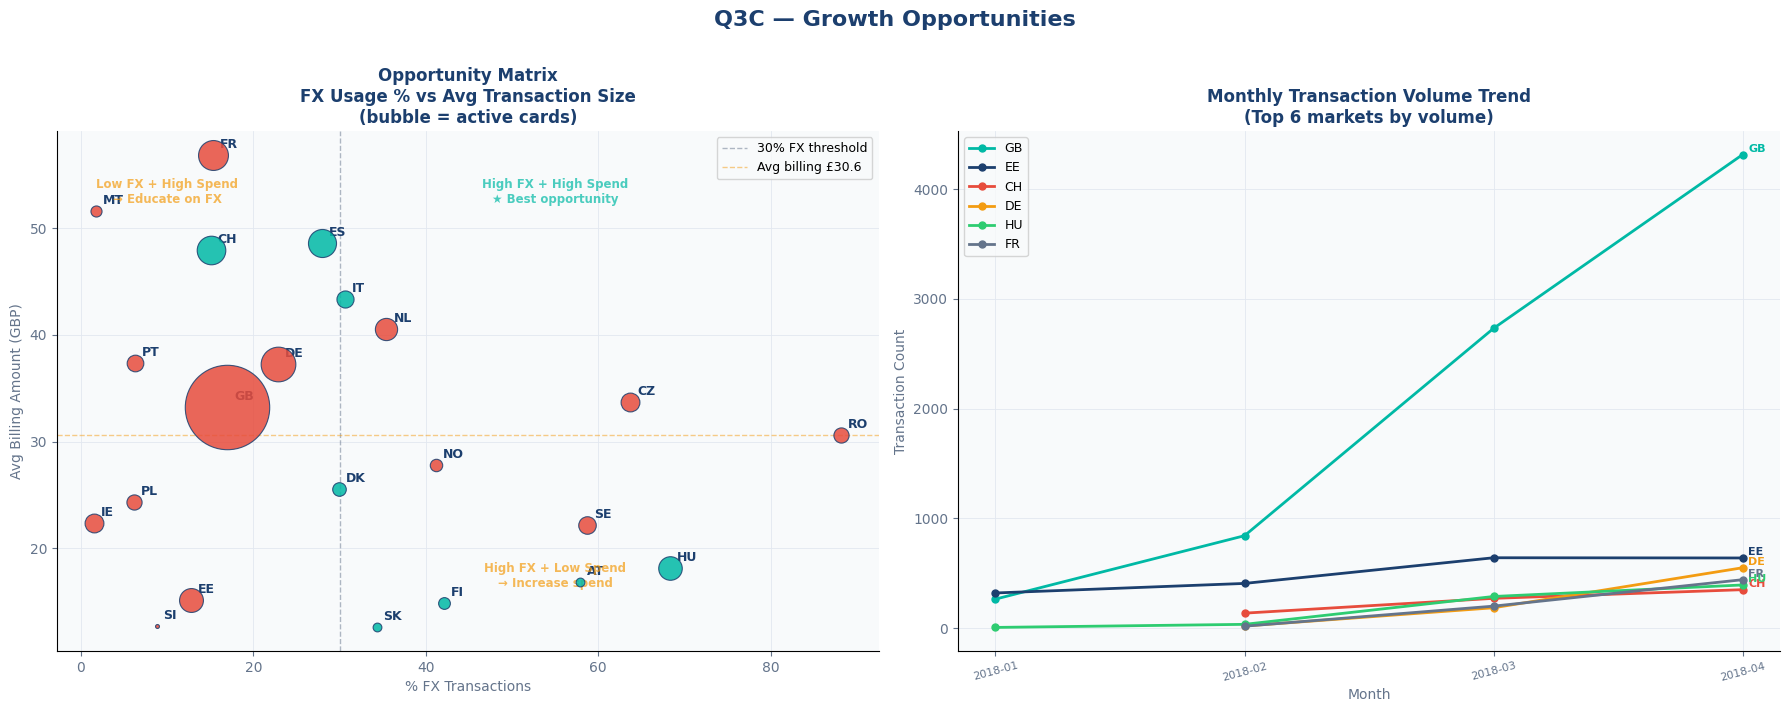

In [64]:
# ── Part C: Growth Opportunity Matrix ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Q3C — Growth Opportunities',
             fontsize=16, fontweight='bold', color=WISE_NAVY, y=1.01)

# Panel 1: Opportunity matrix — FX% vs avg billing (size = txn count)
ax = axes[0]
for _, row in mkt_perf.iterrows():
    clr  = WISE_TEAL if row['total_profit'] > 0 else WISE_RED
    size = row['active_cards'] * 8
    ax.scatter(row['pct_fx_txns'] * 100, row['avg_billing_gbp'],
               s=size, color=clr, edgecolors=WISE_NAVY,
               linewidths=0.8, alpha=0.85, zorder=4)
    ax.annotate(row['country'],
                xy=(row['pct_fx_txns'] * 100, row['avg_billing_gbp']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color=WISE_NAVY)

ax.axvline(30, color=WISE_GRAY, linewidth=1, linestyle='--',
           alpha=0.5, label='30% FX threshold')
ax.axhline(mkt_perf['avg_billing_gbp'].mean(), color=WISE_AMBER,
           linewidth=1, linestyle='--', alpha=0.5,
           label=f'Avg billing £{mkt_perf["avg_billing_gbp"].mean():.1f}')

# Quadrant labels
ax.text(55, mkt_perf['avg_billing_gbp'].max() * 0.92,
        'High FX + High Spend\n★ Best opportunity',
        fontsize=8.5, color=WISE_TEAL, fontweight='bold',
        ha='center', alpha=0.7)
ax.text(10, mkt_perf['avg_billing_gbp'].max() * 0.92,
        'Low FX + High Spend\n→ Educate on FX',
        fontsize=8.5, color=WISE_AMBER, fontweight='bold',
        ha='center', alpha=0.7)
ax.text(55, mkt_perf['avg_billing_gbp'].min() * 1.3,
        'High FX + Low Spend\n→ Increase spend',
        fontsize=8.5, color=WISE_AMBER, fontweight='bold',
        ha='center', alpha=0.7)

ax.set_title('Opportunity Matrix\nFX Usage % vs Avg Transaction Size\n'
             '(bubble = active cards)',
             fontweight='bold', color=WISE_NAVY)
ax.set_xlabel('% FX Transactions', fontsize=10)
ax.set_ylabel('Avg Billing Amount (GBP)', fontsize=10)
ax.legend(fontsize=9)

# Panel 2: Monthly trend for top 6 markets
ax = axes[1]
top6 = mkt_perf.nlargest(6, 'txn_count')['country'].tolist()
line_colors = [WISE_TEAL, WISE_NAVY, WISE_RED,
               WISE_AMBER, WISE_GREEN, WISE_GRAY]

for country, clr in zip(top6, line_colors):
    sub = monthly_trend[monthly_trend['country'] == country]
    ax.plot(sub['month'], sub['txn_count'],
            marker='o', linewidth=2, markersize=5,
            label=country, color=clr, zorder=4)
    # label last point
    if len(sub) > 0:
        last = sub.iloc[-1]
        ax.annotate(country,
                    xy=(last['month'], last['txn_count']),
                    xytext=(4, 2), textcoords='offset points',
                    fontsize=8, fontweight='bold', color=clr)

ax.set_title('Monthly Transaction Volume Trend\n(Top 6 markets by volume)',
             fontweight='bold', color=WISE_NAVY)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Transaction Count', fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.tick_params(axis='x', labelsize=8, rotation=15)

plt.tight_layout()
plt.savefig('q3c_growth_opportunities.png', dpi=150, bbox_inches='tight')
plt.show()